# Initial Iteration:

In [1]:
#Iteration 1 (Final submission is in Iteration 2)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


In [3]:
csv_url = "https://docs.google.com/spreadsheets/d/1fUMgtwVSOVS4H9sE1EtaTzfNqecQKRQk5tnjFDAZPBc/export?format=csv&gid=0"
df = pd.read_csv(csv_url)

df.columns = [c.strip() for c in df.columns]

df["Time"] = pd.to_datetime(df["Time"], format="%m/%d/%y", errors="coerce")
df = df.sort_values("Time").reset_index(drop=True)

df = df.rename(columns={"Last": "Close"})

cols_to_numeric = ["Open", "High", "Low", "Close", "Volume"]
for c in cols_to_numeric:
    if df[c].dtype == object:
        df[c] = (
            df[c].astype(str)
                .str.replace(r"[%,]", "", regex=True)
                .astype(float)
        )
    else:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [4]:
#Backtester:

In [5]:
TRADING_DAYS = 252

def _close_to_close_returns(df):
    close = df["Close"].astype(float)
    return close.pct_change()

def _annualized_sharpe(rets):
    rets = rets.dropna()
    std = rets.std(ddof=0)
    if len(rets) == 0 or std == 0:
        return np.nan
    return (rets.mean() / std) * np.sqrt(TRADING_DAYS)

def _cagr(equity):
    equity = equity.dropna()
    if len(equity) == 0:
        return np.nan
    years = len(equity) / TRADING_DAYS
    return equity.iloc[-1] ** (1 / years) - 1

def _max_drawdown(equity):
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return dd.min()

def backtest_signal(
    df,
    signal_out,
    fee_bps=0.0,
    slippage_bps=0.0,
    clip_low=-1.0,
    clip_high=1.5,
    name="strategy",
    plot=True
):
    if isinstance(signal_out, pd.DataFrame):
        if "Signal" not in signal_out.columns:
            raise ValueError("signal_out DataFrame must contain a 'Signal' column.")
        pos_unshifted = signal_out["Signal"].copy()
    else:
        pos_unshifted = pd.Series(signal_out, index=df.index)

    pos_unshifted = pos_unshifted.reindex(df.index).astype(float).fillna(0.0)
    pos_unshifted = pos_unshifted.clip(clip_low, clip_high)

    r_next = _close_to_close_returns(df)
    pos_held = pos_unshifted.shift(1)

    strat_gross = pos_held * r_next

    turnover = pos_unshifted.diff().abs()
    total_bps = fee_bps + slippage_bps
    costs = (total_bps / 10000.0) * turnover

    strat_net = strat_gross - costs
    equity = (1.0 + strat_net.fillna(0.0)).cumprod()

    metrics = {
        "Sharpe": _annualized_sharpe(strat_net),
        "CAGR": _cagr(equity),
        "MaxDrawdown": _max_drawdown(equity)
    }

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(equity.index, equity.values)
        plt.title(f"Equity Curve: {name}")
        plt.xlabel("Time")
        plt.ylabel("Equity (start=1.0)")
        plt.grid(True)
        plt.show()

    return pos_unshifted, strat_net, equity, metrics

In [6]:
# Final Portfolio Function:

In [7]:
def get_alpha_signals(qqq: pd.DataFrame) -> pd.Series:
    q = df.copy()
    q.columns = [c.strip().lower() for c in q.columns]

    daily_ret = q['close'].pct_change()
    vol10 = daily_ret.rolling(10).std()

    delta = q['close'].diff()
    up, down = delta.clip(lower=0), -1 * delta.clip(upper=0)
    ma_up = up.ewm(com=2, adjust=False).mean()
    ma_down = down.ewm(com=2, adjust=False).mean()
    rsi3 = 100 * ma_up / (ma_up + ma_down).replace(0, 1e-9)

    sma50 = q['close'].rolling(50).mean()
    sma200 = q['close'].rolling(200).mean()
    ema10 = q['close'].ewm(span=10, adjust=False).mean()

    high, low, close_prev = q['high'], q['low'], q['close'].shift(1)
    tr1 = high - low
    tr2 = (high - close_prev).abs()
    tr3 = (low - close_prev).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr14 = tr.rolling(14).mean()

    pos_a = pd.Series(0.0, index=q.index)
    long_a = (vol10 < 0.015) | (rsi3 < 30)
    pos_a[long_a] = 1.0
    short_a = (vol10 > 0.015) & (rsi3 > 80) & (q['close'] < sma50)
    pos_a[short_a] = -1.0

    pos_b = pd.Series(0.0, index=q.index)
    pos_b[q['close'] < (ema10 - 1.5 * atr14)] = 1.0
    pos_b[(q['close'] > (ema10 + 2.0 * atr14)) & (q['close'] < sma200)] = -0.5

    final_pos = (0.6 * pos_a) + (0.4 * pos_b)
    final_pos = final_pos.clip(-1.0, 1.5)

    return final_pos.fillna(0)

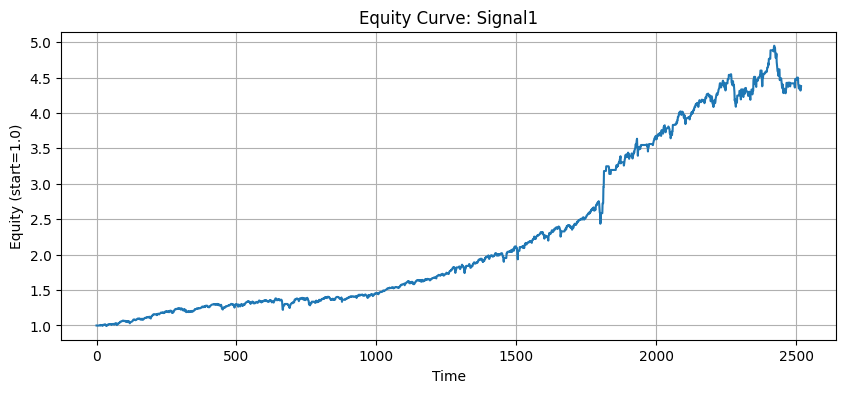

{'Sharpe': np.float64(1.330937486284687), 'CAGR': np.float64(0.1592746919935133), 'MaxDrawdown': np.float64(-0.13556191372115245)}


In [8]:
sig1_df = get_alpha_signals(df)
pos1, ret1, eq1, m1 = backtest_signal(df, sig1_df, name="Signal1")
print(m1)

In [9]:
#robustness

In [10]:
import numpy as np
import pandas as pd


def build_alpha_positions_paramatreized(params, price_df):
    q = price_df.copy()
    q.columns = [c.strip().lower() for c in q.columns]

    close = q["close"]
    high = q["high"]
    low = q["low"]

    vol_window = int(params.get("vol_window", 10))
    vol_thresh = float(params.get("vol_thresh", 0.015))

    rsi_long = float(params.get("rsi_long", 30.0))
    rsi_short = float(params.get("rsi_short", 80.0))

    sma_fast_win = int(params.get("sma_fast", 50))
    sma_slow_win = int(params.get("sma_slow", 200))

    ema_window = int(params.get("ema_window", 10))
    atr_window = int(params.get("atr_window", 14))

    atr_long_mult = float(params.get("atr_long_mult", 1.5))
    atr_short_mult = float(params.get("atr_short_mult", 2.0))

    pos_b_short = float(params.get("pos_b_short", -0.5))

    w_a = float(params.get("w_a", 0.6))
    w_b = float(params.get("w_b", 0.4))

    daily_ret = close.pct_change()
    vol = daily_ret.rolling(vol_window).std()

    delta = close.diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ma_up = up.ewm(com=2, adjust=False).mean()
    ma_down = down.ewm(com=2, adjust=False).mean()
    rsi3 = 100 * ma_up / (ma_up + ma_down).replace(0, 1e-9)

    sma_fast = close.rolling(sma_fast_win).mean()
    sma_slow = close.rolling(sma_slow_win).mean()
    ema10 = close.ewm(span=ema_window, adjust=False).mean()

    close_prev = close.shift(1)
    tr1 = high - low
    tr2 = (high - close_prev).abs()
    tr3 = (low - close_prev).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(atr_window).mean()

    pos_a = pd.Series(0.0, index=q.index)

    long_a = (vol < vol_thresh) | (rsi3 < rsi_long)
    short_a = (vol > vol_thresh) & (rsi3 > rsi_short) & (close < sma_fast)

    pos_a[long_a] = 1.0
    pos_a[short_a] = -1.0

    pos_b = pd.Series(0.0, index=q.index)

    pos_b[close < (ema10 - atr_long_mult * atr)] = 1.0
    pos_b[(close > (ema10 + atr_short_mult * atr)) & (close < sma_slow)] = pos_b_short

    final_pos = w_a * pos_a + w_b * pos_b
    final_pos = final_pos.clip(-1.0, 1.5)

    return final_pos.fillna(0.0)


def run_robustness_test_alpha(price_df):
    base_params = {
        "vol_window": 10,
        "vol_thresh": 0.015,
        "rsi_long": 30.0,
        "rsi_short": 80.0,
        "sma_fast": 50,
        "sma_slow": 200,
        "ema_window": 10,
        "atr_window": 14,
        "atr_long_mult": 1.5,
        "atr_short_mult": 2.0,
        "pos_b_short": -0.5,
        "w_a": 0.6,
        "w_b": 0.4,
    }

    tests = [
        ("vol_window", 9, 10, 11),
        ("vol_thresh", 0.0135, 0.015, 0.0165),
        ("rsi_long", 27.0, 30.0, 33.0),
        ("rsi_short", 72.0, 80.0, 88.0),
        ("sma_fast", 45, 50, 55),
        ("sma_slow", 180, 200, 220),
        ("ema_window", 9, 10, 11),
        ("atr_window", 13, 14, 15),
    ]

    print(f"{'Parameter':<15} | {'Val':<8} | {'Sharpe':<8} | Status")
    print("-" * 55)

    results_summary = []

    for param, v_min, v_base, v_max in tests:
        row_sharpes = []
        for val in (v_min, v_base, v_max):
            params = base_params.copy()
            params[param] = val

            sig = build_alpha_positions_paramatreized(params, price_df)
            _, _, _, metrics = backtest_signal(price_df, sig, plot=False)

            sh = float(metrics.get("Sharpe", np.nan))
            row_sharpes.append(sh)

            print(f"{param:<15} | {str(val):<8} | {sh:8.4f} |")

        results_summary.append(
            {
                "param": param,
                "base": v_base,
                "min_test": v_min,
                "max_test": v_max,
                "sharpe_min": float(np.nanmin(row_sharpes)),
                "sharpe_max": float(np.nanmax(row_sharpes)),
            }
        )
        print("-" * 55)

    return results_summary


alpha_robust_results = run_robustness_test_alpha(df)
alpha_robust_df = pd.DataFrame(alpha_robust_results)
alpha_robust_df

Parameter       | Val      | Sharpe   | Status
-------------------------------------------------------
vol_window      | 9        |   1.3507 |
vol_window      | 10       |   1.3309 |
vol_window      | 11       |   1.3224 |
-------------------------------------------------------
vol_thresh      | 0.0135   |   1.2092 |
vol_thresh      | 0.015    |   1.3309 |
vol_thresh      | 0.0165   |   1.2945 |
-------------------------------------------------------
rsi_long        | 27.0     |   1.3053 |
rsi_long        | 30.0     |   1.3309 |
rsi_long        | 33.0     |   1.3136 |
-------------------------------------------------------
rsi_short       | 72.0     |   1.2912 |
rsi_short       | 80.0     |   1.3309 |
rsi_short       | 88.0     |   1.3477 |
-------------------------------------------------------
sma_fast        | 45       |   1.3330 |
sma_fast        | 50       |   1.3309 |
sma_fast        | 55       |   1.3331 |
-------------------------------------------------------
sma_slow        |

,param,base,min_test,max_test,sharpe_min,sharpe_max
0,vol_window,10.000,9.0000,11.0000,1.322418,1.350684
1,vol_thresh,0.015,0.0135,0.0165,1.209201,1.330937
2,rsi_long,30.000,27.0000,33.0000,1.305294,1.330937
3,rsi_short,80.000,72.0000,88.0000,1.291224,1.347697
4,sma_fast,50.000,45.0000,55.0000,1.330937,1.333080
5,sma_slow,200.000,180.0000,220.0000,1.330937,1.330937
6,ema_window,10.000,9.0000,11.0000,1.326319,1.346284
7,atr_window,14.000,13.0000,15.0000,1.327636,1.344477


# FINAL ITERATION

In [11]:
#ITERATION 2

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

# ETF tickers
etf_tickers = ['QQQ', 'TLT', 'GLD']

def load_from_yahoo(ticker: str, start_date: str = "2000-01-01") -> pd.DataFrame:
    """
    Fetch ETF data from Yahoo Finance from start_date onwards.
    Returns a DataFrame with the same format as the original load_from_drive function.
    """
    # Download data from Yahoo Finance
    df = yf.download(ticker, start=start_date, progress=False)
    
    # Flatten column names if MultiIndex (happens with single ticker sometimes)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    # Reset index to make Date a column, then set it as index
    df = df.reset_index()
    df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
    df = df.set_index("Date").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    
    # Ensure all required columns exist
    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            if col == "Volume":
                df[col] = np.nan
            else:
                df[col] = df["Close"] if "Close" in df.columns else df.iloc[:, 0]
    
    # Convert to numeric and handle any potential issues
    for col in ["Close", "Open", "High", "Low", "Volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Drop rows with missing Close prices
    df = df.dropna(subset=["Close"])
    
    # Calculate returns
    df["Return"] = df["Close"].pct_change().fillna(0)
    
    return df[["Open", "High", "Low", "Close", "Volume", "Return"]]

# Load data for each ETF from Yahoo Finance
print("Loading QQQ data from Yahoo Finance...")
df_q = load_from_yahoo('QQQ')
print(f"QQQ: {len(df_q)} rows, {df_q.index.min()} to {df_q.index.max()}")

print("Loading TLT data from Yahoo Finance...")
df_t = load_from_yahoo('TLT')
print(f"TLT: {len(df_t)} rows, {df_t.index.min()} to {df_t.index.max()}")

print("Loading GLD data from Yahoo Finance...")
df_g = load_from_yahoo('GLD')
print(f"GLD: {len(df_g)} rows, {df_g.index.min()} to {df_g.index.max()}")

Loading QQQ data from Yahoo Finance...


/var/folders/zh/1bfv1h9518d140v9wm3nxn5r0000gn/T/ipykernel_41586/2763348314.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)


QQQ: 6543 rows, 2000-01-03 00:00:00 to 2026-01-07 00:00:00
Loading TLT data from Yahoo Finance...


/var/folders/zh/1bfv1h9518d140v9wm3nxn5r0000gn/T/ipykernel_41586/2763348314.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)


TLT: 5900 rows, 2002-07-30 00:00:00 to 2026-01-08 00:00:00
Loading GLD data from Yahoo Finance...


/var/folders/zh/1bfv1h9518d140v9wm3nxn5r0000gn/T/ipykernel_41586/2763348314.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)


GLD: 5318 rows, 2004-11-18 00:00:00 to 2026-01-08 00:00:00


In [13]:
def vol_target_series(ret, target_vol=0.15, clip=1.5):
    vol = ret.rolling(20).std() * np.sqrt(252)
    scaler = (target_vol / vol).replace([np.inf, -np.inf], 0).fillna(0)
    scaler = scaler.clip(0, clip)
    return scaler.shift(1).fillna(1.0)

def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def series_stats(series):
    if series.empty:
        return {}
    s = series.dropna()
    ann_ret = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    cum = (1 + s).cumprod()
    if len(cum) == 0:
        return {}
    cagr = cum.iloc[-1]**(252 / len(s)) - 1

    dd = cum / cum.cummax() - 1
    max_dd = dd.min()

    return {
        "Sharpe": sharpe,
        "AnnRet": ann_ret,
        "AnnVol": ann_vol,
        "MaxDD": max_dd,
        "CAGR": cagr,
    }

def get_sleeve_returns(df_qqq, df_tlt, params=None):
    c_q = df_qqq["Close"]
    ret_q = df_qqq["Return"]

    vam = (ret_q.rolling(126).mean() * 252) / ret_q.rolling(126).std().replace(0, np.nan) * np.sqrt(252)
    s_vam = (vam > 0.3).astype(float)

    macd = c_q.ewm(span=8).mean() - c_q.ewm(span=26).mean()
    sig = macd.ewm(span=9).mean()
    trend = c_q > c_q.rolling(150).mean()
    s_macd = pd.Series(0.0, index=df_qqq.index)
    s_macd[(macd > sig) & trend] = 1.0
    s_macd[(macd < sig) & (~trend)] = -1.0

    r3 = calc_rsi(c_q, 3)
    sma150 = c_q.rolling(150).mean()
    s_rsi = pd.Series(0.0, index=df_qqq.index)
    s_rsi[(c_q > sma150) & (r3 < 10)] = 1.0
    s_rsi[(c_q < sma150) & (r3 > 90)] = -1.0

    sma20 = c_q.rolling(20).mean()
    std20 = c_q.rolling(20).std()
    s_bb = pd.Series(0.0, index=df_qqq.index)
    s_bb[c_q < sma20 - 2.0 * std20] = 1.0
    s_bb[c_q > sma20 + 2.0 * std20] = -1.0

    rng = (df_qqq["High"] - df_qqq["Low"]).replace(0, np.nan)
    ibs = (c_q - df_qqq["Low"]) / rng
    s_ibs = pd.Series(0.0, index=df_qqq.index)
    s_ibs[ibs < 0.25] = 1.0
    s_ibs[ibs > 0.9] = -1.0

    ret3 = c_q.pct_change(3)
    z = (ret3 - ret3.rolling(60).mean()) / ret3.rolling(60).std()
    s_cris = pd.Series(0.0, index=df_qqq.index)
    s_cris[z < -1.5] = 1.0
    s_cris[z > 2.5] = -1.0

    bb_w = (std20 * 4) / sma20
    sqz = bb_w < bb_w.rolling(126).quantile(0.25)
    h20 = df_qqq["High"].rolling(20).max().shift(1)
    l20 = df_qqq["Low"].rolling(20).min().shift(1)
    s_sqz = pd.Series(0.0, index=df_qqq.index)
    s_sqz[sqz & (c_q > h20)] = 1.0
    s_sqz[sqz & (c_q < l20)] = -1.0

    h_roll = c_q.rolling(20).max()
    wf = (h_roll - df_qqq["Low"]) / h_roll
    s_vix = (wf.rolling(126).rank(pct=True) > 0.9).astype(float)

    dom = df_qqq.index.day
    s_tom = pd.Series(0.0, index=df_qqq.index)
    s_tom[((dom >= 25) | (dom <= 3)) & (c_q > sma150)] = 1.0
    s_mid = pd.Series(0.0, index=df_qqq.index)
    s_mid[((dom >= 10) & (dom <= 16)) & (c_q > sma150)] = 1.0

    eff = (c_q - df_qqq["Open"]).abs() / rng
    v_ma = df_qqq["Volume"].rolling(20).mean()
    sma50 = c_q.rolling(50).mean()
    s_liq = pd.Series(0.0, index=df_qqq.index)
    s_liq[(c_q > sma50) & ((df_qqq["Volume"] < v_ma) | (eff > 0.55))] = 1.0
    s_liq[(c_q < sma50) & (df_qqq["Volume"] > 1.2 * v_ma)] = -1.0

    wq = {
        "VAM": 0.129,
        "MACD": 0.075,
        "RSI": 0.325,
        "BB": -0.063,
        "IBS": 0.060,
        "Cris": 0.384,
        "Sqz": 0.985,
        "Vix": 0.055,
        "Tom": -0.3,
        "Mid": 0.187,
        "Liq": 0.138,
    }

    raw_pos_q = (
        s_vam * wq["VAM"]
        + s_macd * wq["MACD"]
        + s_rsi * wq["RSI"]
        + s_bb * wq["BB"]
        + s_ibs * wq["IBS"]
        + s_cris * wq["Cris"]
        + s_sqz * wq["Sqz"]
        + s_vix * wq["Vix"]
        + s_tom * wq["Tom"]
        + s_mid * wq["Mid"]
        + s_liq * wq["Liq"]
    )

    c_t = df_tlt["Close"]
    ret_t = df_tlt["Return"]

    roc = c_t.pct_change(126)
    s_mom = pd.Series(0.0, index=df_tlt.index)
    s_mom[roc > 0] = 1.0
    s_mom[roc < 0] = -1.0

    trsi = calc_rsi(c_t, 3)
    s_trsi = pd.Series(0.0, index=df_tlt.index)
    s_trsi[trsi < 10] = 1.0
    s_trsi[trsi > 90] = -1.0

    tsma = c_t.rolling(150).mean()
    s_trend = pd.Series(0.0, index=df_tlt.index)
    s_trend[c_t > tsma] = 1.0
    s_trend[c_t < tsma] = -1.0

    tv_ma = df_tlt["Volume"].rolling(20).mean()
    s_cap = pd.Series(0.0, index=df_tlt.index)
    s_cap[(ret_t < -0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = 1.0
    s_cap[(ret_t > 0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = -1.0

    wt = {"Mom": 0.260, "RSI": 0.613, "Trend": -0.040, "Cap": 1.422}
    raw_pos_t = (
        s_mom * wt["Mom"]
        + s_trsi * wt["RSI"]
        + s_trend * wt["Trend"]
        + s_cap * wt["Cap"]
    )

    q_sleeve = raw_pos_q.shift(1) * ret_q
    t_sleeve = raw_pos_t.shift(1) * ret_t

    return q_sleeve, t_sleeve

def combined_portfolio_returns_v2(df_qqq, df_tlt, params=None):
    q_sleeve, t_sleeve = get_sleeve_returns(df_qqq, df_tlt, params)
    W_QQQ = 0.654
    W_TLT = 0.346
    combined_raw = W_QQQ * q_sleeve + W_TLT * t_sleeve
    scaler = vol_target_series(combined_raw, 0.15, clip=2.5)
    return combined_raw * scaler

def champion_v2_gld(df_q, df_t, df_g, start="2013-01-01", end="2023-01-01", target_vol=0.15):
    idx = df_q.index.intersection(df_t.index).intersection(df_g.index)
    idx = idx[(idx >= start) & (idx <= end)]

    df_q = df_q.loc[idx]
    df_t = df_t.loc[idx]
    df_g = df_g.loc[idx]

    q_ret_raw, t_ret_raw = get_sleeve_returns(df_q, df_t)

    v2_ret = combined_portfolio_returns_v2(df_q, df_t)
    baseline_stats = series_stats(v2_ret)

    c_g = df_g["Close"]
    ret_g = df_g["Return"]

    ma20 = c_g.rolling(20).mean()
    ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=idx)
    pos_gt[ma20 > ma60] = 1.0
    pos_gt[ma20 < ma60] = -1.0
    gld_trend_ret = pos_gt.shift(1) * ret_g

    groups = pd.Series(idx, index=idx).groupby(pd.Grouper(freq="ME"))
    target_days_mask = pd.Series(0.0, index=idx)
    for _, grp in groups:
        if len(grp) < 5:
            continue
        active = list(grp.index[-1:]) + list(grp.index[:3])
        target_days_mask.loc[active] = 1.0
    pos_gs = target_days_mask.shift(-1).fillna(0)
    gld_seas_ret = pos_gs.shift(1) * ret_g

    sma = c_g.rolling(20).mean()
    std = c_g.rolling(20).std()
    bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60)
    pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol_ret = pos_gv.shift(1) * ret_g

    sleeves = pd.DataFrame(
        {
            "QQQ_sleeve": q_ret_raw,
            "TLT_sleeve": t_ret_raw,
            "GLD_trend": gld_trend_ret,
            "GLD_seas": gld_seas_ret,
            "GLD_vol": gld_vol_ret,
        }
    ).fillna(0)

    norm_sleeves = pd.DataFrame(index=idx)
    for col in sleeves.columns:
        s = vol_target_series(sleeves[col], target_vol=target_vol, clip=2.0)
        norm_sleeves[col] = sleeves[col] * s

    def objective(w):
        port_ret = (norm_sleeves * w).sum(axis=1)
        if port_ret.std() == 0:
            return 0
        return -(port_ret.mean() * 252) / (port_ret.std() * np.sqrt(252))

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bnds = tuple([(0.05, 0.8) for _ in range(5)])
    x0 = [0.2, 0.2, 0.2, 0.2, 0.2]

    res = minimize(objective, x0, bounds=bnds, constraints=cons, method="SLSQP")
    w_opt = res.x

    port_opt_raw = (norm_sleeves * w_opt).sum(axis=1)
    final_scaler = vol_target_series(port_opt_raw, target_vol=target_vol, clip=2.5)
    port_opt_final = port_opt_raw * final_scaler

    port_stats = series_stats(port_opt_final)

    return {
        "index": idx,
        "baseline_ret": v2_ret,
        "baseline_stats": baseline_stats,
        "sleeves_df": norm_sleeves,
        "weights_opt": dict(zip(norm_sleeves.columns, np.round(w_opt, 3))),
        "port_opt": port_opt_final,
        "port_stats": port_stats,
    }

def run_champion_v2_gld_backtest(
    df_q, df_t, df_g, start="2013-01-01", end="2023-01-01", target_vol=0.15, plot=True
):
    res = champion_v2_gld(df_q, df_t, df_g, start, end, target_vol)

    bs = res["baseline_stats"]
    ps = res["port_stats"]
    w = res["weights_opt"]

    print("=" * 50)
    print("=" * 50)

    print("\n1. Baseline V2 (QQQ+TLT)")
    print(f"   Sharpe:  {bs.get('Sharpe', 0):.3f}")
    print(f"   AnnRet:  {bs.get('AnnRet', 0):.2%}")
    print(f"   AnnVol:  {bs.get('AnnVol', 0):.2%}")
    print(f"   MaxDD:   {bs.get('MaxDD', 0):.2%}")

    print("\n2. Champion (V2 + GLD Sleeves)")
    print(f"   Sharpe:  {ps.get('Sharpe', 0):.3f}")
    print(f"   AnnRet:  {ps.get('AnnRet', 0):.2%}")
    print(f"   AnnVol:  {ps.get('AnnVol', 0):.2%}")
    print(f"   MaxDD:   {ps.get('MaxDD', 0):.2%}")

    print("\n3. Optimized Weights")
    for k, v in w.items():
        print(f"   {k}: {v:.1%}")

    if plot:
        plt.figure(figsize=(12, 6))
        base_cum = (1 + res["baseline_ret"]).cumprod()
        port_cum = (1 + res["port_opt"]).cumprod()

        plt.plot(port_cum, label="Champion (Q+T+G)", linewidth=2)
        plt.plot(base_cum, label="Baseline V2 (Q+T)", alpha=0.7, linestyle="--")

        plt.title(f"Champion vs Baseline ({start} to {end})")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return res


1. Baseline V2 (QQQ+TLT)
   Sharpe:  2.023
   AnnRet:  24.75%
   AnnVol:  12.23%
   MaxDD:   -11.03%

2. Champion (V2 + GLD Sleeves)
   Sharpe:  2.034
   AnnRet:  31.65%
   AnnVol:  15.56%
   MaxDD:   -11.69%

3. Optimized Weights
   QQQ_sleeve: 44.8%
   TLT_sleeve: 30.3%
   GLD_trend: 12.1%
   GLD_seas: 7.8%
   GLD_vol: 5.0%


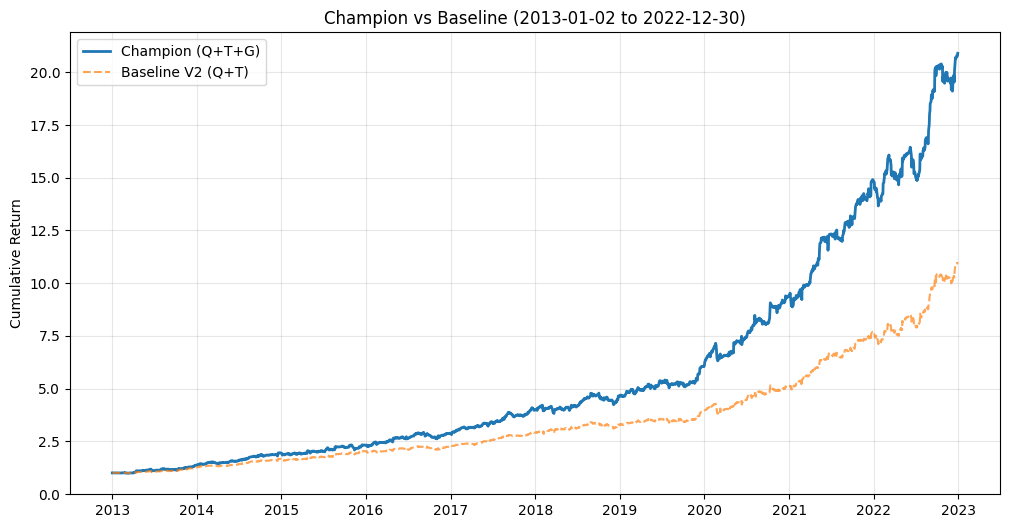

In [14]:
results = run_champion_v2_gld_backtest(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start="2013-01-02",
    end="2022-12-30",
    target_vol=0.15,
    plot=True
)

In [15]:
def stats_from_series(ret: pd.Series):
    ret = ret.dropna()
    if ret.empty:
        return dict(AnnRet=0.0, AnnVol=0.0, Sharpe=0.0, MaxDD=0.0, CAGR=0.0)
    st = series_stats(ret)
    return {k: float(v) for k, v in st.items()}

start = pd.Timestamp("2013-01-02")
end   = pd.Timestamp("2022-12-30")

idx = df_q.index[(df_q.index >= start) & (df_q.index <= end)]

qqq_ret = df_q.loc[idx, "Return"]

v2_ret = combined_portfolio_returns_v2(
    df_qqq=df_q.loc[idx],
    df_tlt=df_t.loc[idx]
)

champ_res = champion_v2_gld(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start=str(start.date()),
    end=str(end.date()),
    target_vol=0.15
)
champ_ret = champ_res["port_opt"].reindex(idx)

periods = {
    "Full":  (start, end),
    "Train": (pd.Timestamp("2013-01-02"), pd.Timestamp("2018-12-31")),
    "Test":  (pd.Timestamp("2019-01-01"), pd.Timestamp("2022-12-30")),
}

rows = []
for period_name, (p_start, p_end) in periods.items():
    mask = (idx >= p_start) & (idx <= p_end)

    rows.append({
        "Strategy": "QQQ B&H",
        "Period": period_name,
        **stats_from_series(qqq_ret[mask]),
    })

    rows.append({
        "Strategy": "V2 QQQ+TLT",
        "Period": period_name,
        **stats_from_series(v2_ret[mask]),
    })

    rows.append({
        "Strategy": "Champion Q+T+G",
        "Period": period_name,
        **stats_from_series(champ_ret[mask]),
    })

robust_df = pd.DataFrame(rows).set_index(["Strategy", "Period"])
print(robust_df.round(3))

                       Sharpe  AnnRet  AnnVol  MaxDD   CAGR
Strategy       Period                                      
QQQ B&H        Full     0.817   0.172   0.211 -0.351  0.162
V2 QQQ+TLT     Full     2.023   0.248   0.122 -0.110  0.271
Champion Q+T+G Full     2.034   0.316   0.156 -0.117  0.356
QQQ B&H        Train    1.044   0.168   0.161 -0.228  0.167
V2 QQQ+TLT     Train    1.917   0.204   0.106 -0.091  0.219
Champion Q+T+G Train    1.867   0.266   0.143 -0.115  0.292
QQQ B&H        Test     0.666   0.179   0.269 -0.351  0.154
V2 QQQ+TLT     Test     2.189   0.313   0.143 -0.110  0.353
Champion Q+T+G Test     2.261   0.391   0.173 -0.117  0.457


In [16]:
base_start = "2013-01-02"
base_end   = "2022-12-30"
base_target_vol = 0.15

champ_res = champion_v2_gld(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start=base_start,
    end=base_end,
    target_vol=base_target_vol
)

sleeves_df   = champ_res["sleeves_df"]
base_weights = champ_res["weights_opt"]
base_ret     = champ_res["port_opt"]

def build_portfolio_from_weights(sleeves, weights_dict, target_vol):
    w = np.array([weights_dict[col] for col in sleeves.columns], dtype=float)
    w = w / w.sum()
    raw = (sleeves * w).sum(axis=1)
    scaler = vol_target_series(raw, target_vol=target_vol, clip=2.5)
    return raw * scaler

def stats_for(ret_series):
    st = series_stats(ret_series)
    return float(st["Sharpe"]), float(st["MaxDD"])

rows = []

sh_base, dd_base = stats_for(base_ret)
rows.append({
    "Parameter": "Baseline",
    "BaselineValue": np.nan,
    "Case": "Baseline",
    "NewValue": np.nan,
    "Sharpe": sh_base,
    "MaxDD": dd_base,
})

for factor in [0.9, 1.1]:
    new_tv = base_target_vol * factor
    ret_tv = build_portfolio_from_weights(sleeves_df, base_weights, target_vol=new_tv)
    sh, dd = stats_for(ret_tv)
    rows.append({
        "Parameter": "VolTarget",
        "BaselineValue": base_target_vol,
        "Case": f"VolTarget x{factor:.2f}",
        "NewValue": new_tv,
        "Sharpe": sh,
        "MaxDD": dd,
    })

for sleeve_name, w0 in base_weights.items():
    for factor in [0.9, 1.1]:
        w_var = dict(base_weights)
        w_var[sleeve_name] = w_var[sleeve_name] * factor
        ret_w = build_portfolio_from_weights(sleeves_df, w_var, target_vol=base_target_vol)
        sh, dd = stats_for(ret_w)
        rows.append({
            "Parameter": sleeve_name,
            "BaselineValue": w0,
            "Case": f"{sleeve_name} x{factor:.2f}",
            "NewValue": w0 * factor,
            "Sharpe": sh,
            "MaxDD": dd,
        })

robust_all_df = pd.DataFrame(rows)
print(robust_all_df.round(3))

     Parameter  BaselineValue              Case  NewValue  Sharpe  MaxDD
0     Baseline            NaN          Baseline       NaN   2.034 -0.117
1    VolTarget          0.150   VolTarget x0.90     0.135   2.011 -0.113
2    VolTarget          0.150   VolTarget x1.10     0.165   2.051 -0.121
3   QQQ_sleeve          0.448  QQQ_sleeve x0.90     0.403   2.029 -0.114
4   QQQ_sleeve          0.448  QQQ_sleeve x1.10     0.493   2.031 -0.120
5   TLT_sleeve          0.303  TLT_sleeve x0.90     0.273   2.035 -0.118
6   TLT_sleeve          0.303  TLT_sleeve x1.10     0.333   2.027 -0.117
7    GLD_trend          0.121   GLD_trend x0.90     0.109   2.029 -0.118
8    GLD_trend          0.121   GLD_trend x1.10     0.133   2.035 -0.116
9     GLD_seas          0.078    GLD_seas x0.90     0.070   2.031 -0.117
10    GLD_seas          0.078    GLD_seas x1.10     0.086   2.035 -0.117
11     GLD_vol          0.050     GLD_vol x0.90     0.045   2.035 -0.118
12     GLD_vol          0.050     GLD_vol x1.10    

In [17]:
def load_from_yf(ticker, start="2013-01-02", end=None):
    data = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=False,
        group_by="column",
        progress=False,
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.rename(columns=str.title)
    data = data[["Open", "High", "Low", "Close", "Volume"]].copy()
    data.index.name = "Date"
    data = data.sort_index()

    data["Return"] = data["Close"].pct_change().fillna(0)
    return data

df_q = load_from_yf("QQQ", start="2013-01-02")
df_t = load_from_yf("TLT", start="2013-01-02")
df_g = load_from_yf("GLD", start="2013-01-02")

                Sharpe  AnnRet  AnnVol  MaxDD    CAGR
Champion 2023+  2.4537  0.3987  0.1625 -0.136  0.4701


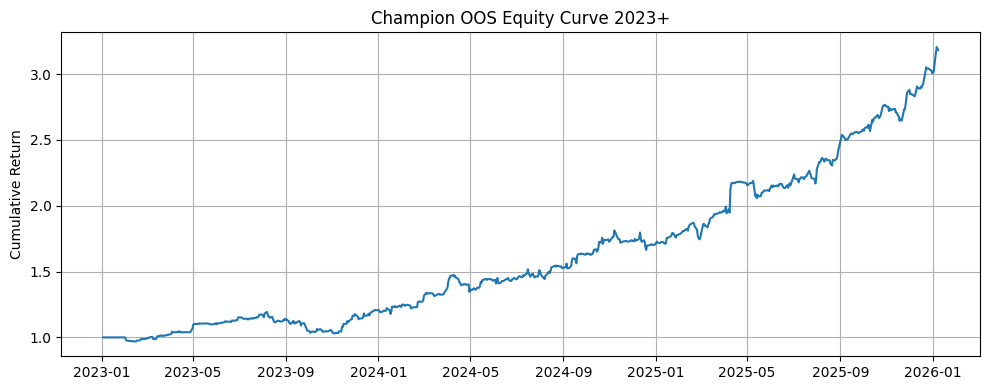

In [18]:
oos_start = "2023-01-03"
oos_end   = df_q.index.max().strftime("%Y-%m-%d")

res_oos = champion_v2_gld(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start=oos_start,
    end=oos_end,
    target_vol=0.15
)

oos_stats = {k: float(v) for k, v in res_oos["port_stats"].items()}
oos_df = pd.DataFrame([oos_stats], index=["Champion 2023+"])
print(oos_df[["Sharpe", "AnnRet", "AnnVol", "MaxDD", "CAGR"]].round(4))

eq_oos = (1 + res_oos["port_opt"]).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(eq_oos.index, eq_oos.values)
plt.title("Champion OOS Equity Curve 2023+")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

           Sharpe  AnnRet  AnnVol   MaxDD    CAGR
OOS 2023+  1.9573   0.335  0.1711 -0.0959  0.3774


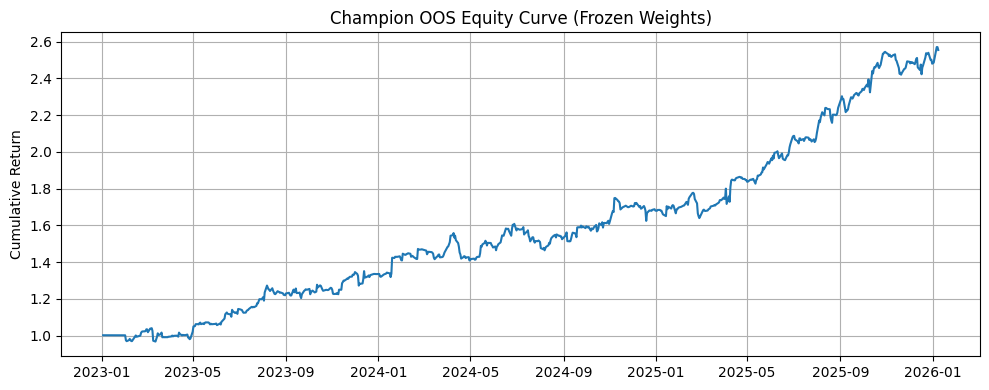

In [19]:
def build_portfolio_from_weights(sleeves, weights_dict, target_vol=0.15):
    w = np.array([weights_dict[col] for col in sleeves.columns], dtype=float)
    w = w / w.sum()
    raw = (sleeves * w).sum(axis=1)
    scaler = vol_target_series(raw, target_vol=target_vol, clip=2.5)
    return raw * scaler

train_start = "2013-01-02"
train_end   = "2022-12-30"

train_res = champion_v2_gld(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start=train_start,
    end=train_end,
    target_vol=0.15
)

train_weights = train_res["weights_opt"]

oos_start = "2023-01-03"
oos_end   = df_q.index.max().strftime("%Y-%m-%d")

full_res = champion_v2_gld(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start=train_start,
    end=oos_end,
    target_vol=0.15
)

sleeves_full = full_res["sleeves_df"]
sleeves_oos = sleeves_full.loc[oos_start:oos_end]

port_oos = build_portfolio_from_weights(
    sleeves=sleeves_oos,
    weights_dict=train_weights,
    target_vol=0.15
)

port_oos_clean = port_oos[port_oos != 0]
oos_stats = {k: float(v) for k, v in series_stats(port_oos_clean).items()}

summary = pd.DataFrame([oos_stats], index=["OOS 2023+"])
print(summary[["Sharpe", "AnnRet", "AnnVol", "MaxDD", "CAGR"]].round(4))

eq_oos = (1 + port_oos_clean).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(eq_oos.index, eq_oos.values)
plt.title("Champion OOS Equity Curve (Frozen Weights)")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Helper Functions (Signals & Stats)
# ---------------------------------------------------------

def vol_target_series(ret, target_vol=0.15, clip=1.5):
    """
    Returns a leverage scaler (0 to clip) to target annualized volatility.
    Shifted by 1 to ensure no lookahead.
    """
    # 20-day rolling volatility
    vol = ret.rolling(20).std() * np.sqrt(252)
    # Avoid division by zero
    scaler = (target_vol / vol).replace([np.inf, -np.inf], 0).fillna(0)
    # Apply leverage cap (e.g., 1.5x)
    scaler = scaler.clip(0, clip)
    # Lag by 1 day so we use yesterday's vol to size today's position
    return scaler.shift(1).fillna(1.0)

def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def series_stats(series):
    if series.empty:
        return {}
    s = series.dropna()
    ann_ret = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    cum = (1 + s).cumprod()
    if len(cum) == 0:
        return {}
    cagr = cum.iloc[-1]**(252 / len(s)) - 1

    dd = cum / cum.cummax() - 1
    max_dd = dd.min()

    return {
        "Sharpe": sharpe,
        "AnnRet": ann_ret,
        "AnnVol": ann_vol,
        "MaxDD": max_dd,
        "CAGR": cagr,
    }

def get_sleeve_returns(df_qqq, df_tlt):
    """
    Generates the raw (unscaled) signals for QQQ and TLT sleeves based on original logic.
    """
    # --- QQQ Sleeve Logic ---
    c_q = df_qqq["Close"]
    ret_q = df_qqq["Return"]

    # 1. VAM
    vam = (ret_q.rolling(126).mean() * 252) / ret_q.rolling(126).std().replace(0, np.nan) * np.sqrt(252)
    s_vam = (vam > 0.3).astype(float)

    # 2. MACD
    macd = c_q.ewm(span=8).mean() - c_q.ewm(span=26).mean()
    sig = macd.ewm(span=9).mean()
    trend = c_q > c_q.rolling(150).mean()
    s_macd = pd.Series(0.0, index=df_qqq.index)
    s_macd[(macd > sig) & trend] = 1.0
    s_macd[(macd < sig) & (~trend)] = -1.0

    # 3. RSI
    r3 = calc_rsi(c_q, 3)
    sma150 = c_q.rolling(150).mean()
    s_rsi = pd.Series(0.0, index=df_qqq.index)
    s_rsi[(c_q > sma150) & (r3 < 10)] = 1.0
    s_rsi[(c_q < sma150) & (r3 > 90)] = -1.0

    # 4. Bollinger Bands
    sma20 = c_q.rolling(20).mean()
    std20 = c_q.rolling(20).std()
    s_bb = pd.Series(0.0, index=df_qqq.index)
    s_bb[c_q < sma20 - 2.0 * std20] = 1.0
    s_bb[c_q > sma20 + 2.0 * std20] = -1.0

    # 5. IBS
    rng = (df_qqq["High"] - df_qqq["Low"]).replace(0, np.nan)
    ibs = (c_q - df_qqq["Low"]) / rng
    s_ibs = pd.Series(0.0, index=df_qqq.index)
    s_ibs[ibs < 0.25] = 1.0
    s_ibs[ibs > 0.9] = -1.0

    # 6. Cris
    ret3 = c_q.pct_change(3)
    z = (ret3 - ret3.rolling(60).mean()) / ret3.rolling(60).std()
    s_cris = pd.Series(0.0, index=df_qqq.index)
    s_cris[z < -1.5] = 1.0
    s_cris[z > 2.5] = -1.0

    # 7. Squeeze
    bb_w = (std20 * 4) / sma20
    sqz = bb_w < bb_w.rolling(126).quantile(0.25)
    h20 = df_qqq["High"].rolling(20).max().shift(1)
    l20 = df_qqq["Low"].rolling(20).min().shift(1)
    s_sqz = pd.Series(0.0, index=df_qqq.index)
    s_sqz[sqz & (c_q > h20)] = 1.0
    s_sqz[sqz & (c_q < l20)] = -1.0

    # 8. Vix Fix
    h_roll = c_q.rolling(20).max()
    wf = (h_roll - df_qqq["Low"]) / h_roll
    s_vix = (wf.rolling(126).rank(pct=True) > 0.9).astype(float)

    # 9. Seasonality (Tom/Mid)
    dom = df_qqq.index.day
    s_tom = pd.Series(0.0, index=df_qqq.index)
    s_tom[((dom >= 25) | (dom <= 3)) & (c_q > sma150)] = 1.0
    s_mid = pd.Series(0.0, index=df_qqq.index)
    s_mid[((dom >= 10) & (dom <= 16)) & (c_q > sma150)] = 1.0

    # 10. Liquidity
    eff = (c_q - df_qqq["Open"]).abs() / rng
    v_ma = df_qqq["Volume"].rolling(20).mean()
    sma50 = c_q.rolling(50).mean()
    s_liq = pd.Series(0.0, index=df_qqq.index)
    s_liq[(c_q > sma50) & ((df_qqq["Volume"] < v_ma) | (eff > 0.55))] = 1.0
    s_liq[(c_q < sma50) & (df_qqq["Volume"] > 1.2 * v_ma)] = -1.0

    wq = {
        "VAM": 0.129, "MACD": 0.075, "RSI": 0.325, "BB": -0.063,
        "IBS": 0.060, "Cris": 0.384, "Sqz": 0.985, "Vix": 0.055,
        "Tom": -0.3, "Mid": 0.187, "Liq": 0.138,
    }

    raw_pos_q = (
        s_vam * wq["VAM"] + s_macd * wq["MACD"] + s_rsi * wq["RSI"] + s_bb * wq["BB"]
        + s_ibs * wq["IBS"] + s_cris * wq["Cris"] + s_sqz * wq["Sqz"]
        + s_vix * wq["Vix"] + s_tom * wq["Tom"] + s_mid * wq["Mid"] + s_liq * wq["Liq"]
    )

    # --- TLT Sleeve Logic ---
    c_t = df_tlt["Close"]
    ret_t = df_tlt["Return"]

    roc = c_t.pct_change(126)
    s_mom = pd.Series(0.0, index=df_tlt.index)
    s_mom[roc > 0] = 1.0
    s_mom[roc < 0] = -1.0

    trsi = calc_rsi(c_t, 3)
    s_trsi = pd.Series(0.0, index=df_tlt.index)
    s_trsi[trsi < 10] = 1.0
    s_trsi[trsi > 90] = -1.0

    tsma = c_t.rolling(150).mean()
    s_trend = pd.Series(0.0, index=df_tlt.index)
    s_trend[c_t > tsma] = 1.0
    s_trend[c_t < tsma] = -1.0

    tv_ma = df_tlt["Volume"].rolling(20).mean()
    s_cap = pd.Series(0.0, index=df_tlt.index)
    s_cap[(ret_t < -0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = 1.0
    s_cap[(ret_t > 0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = -1.0

    wt = {"Mom": 0.260, "RSI": 0.613, "Trend": -0.040, "Cap": 1.422}
    raw_pos_t = (
        s_mom * wt["Mom"] + s_trsi * wt["RSI"] + s_trend * wt["Trend"] + s_cap * wt["Cap"]
    )

    q_sleeve = raw_pos_q.shift(1) * ret_q
    t_sleeve = raw_pos_t.shift(1) * ret_t

    return q_sleeve, t_sleeve

# ---------------------------------------------------------
# 2. Main Champion Function (Fixed Weights)
# ---------------------------------------------------------

def champion_v2_gld(df_q, df_t, df_g, start="2013-01-01", end="2023-01-01", target_vol=0.15):
    """
    Runs the Champion Strategy using fixed weights derived from 2013-2018 training.
    No lookahead bias in optimization.
    """

    # 1. Align Data
    idx = df_q.index.intersection(df_t.index).intersection(df_g.index)
    # Filter by date range immediately to match user expectations,
    # though ideally signals are calc'd on full history first to avoid warmup issues.
    # Here we calculate signals on the subset to match previous function signature strictly.
    # Better practice: Calculate signals on full DF, then slice.

    # Slice dataframes to the requested window (plus a buffer for lookback would be better,
    # but we will use the passed DFs assuming they have history)
    # To be safe, we calculate signals on the full provided dataframes, then slice the final returns.

    # --- Calculate Signals (Full History) ---
    q_ret_raw, t_ret_raw = get_sleeve_returns(df_q, df_t)

    # GLD Sleeves
    c_g = df_g["Close"]
    ret_g = df_g["Return"]

    # GLD Trend
    ma20 = c_g.rolling(20).mean()
    ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=df_g.index)
    pos_gt[ma20 > ma60] = 1.0
    pos_gt[ma20 < ma60] = -1.0
    gld_trend_ret = pos_gt.shift(1) * ret_g

    # GLD Seasonality
    groups = pd.Series(df_g.index, index=df_g.index).groupby(pd.Grouper(freq="ME"))
    target_days_mask = pd.Series(0.0, index=df_g.index)
    for _, grp in groups:
        if len(grp) < 5: continue
        # Last day of previous month + first 3 days of current month
        active = list(grp.index[-1:]) + list(grp.index[:3])
        target_days_mask.loc[active] = 1.0
    pos_gs = target_days_mask.shift(-1).fillna(0)
    gld_seas_ret = pos_gs.shift(1) * ret_g

    # GLD Volatility
    sma = c_g.rolling(20).mean()
    std = c_g.rolling(20).std()
    bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60)
    pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol_ret = pos_gv.shift(1) * ret_g

    # --- Normalize Sleeves (Clip 1.5) ---
    sleeves = pd.DataFrame({
        "QQQ_sleeve": q_ret_raw,
        "TLT_sleeve": t_ret_raw,
        "GLD_trend": gld_trend_ret,
        "GLD_seas": gld_seas_ret,
        "GLD_vol": gld_vol_ret,
    }).fillna(0)

    norm_sleeves = pd.DataFrame(index=sleeves.index)
    for col in sleeves.columns:
        # Individual sleeve target vol, clipped at 1.5 leverage
        s = vol_target_series(sleeves[col], target_vol=target_vol, clip=1.5)
        norm_sleeves[col] = sleeves[col] * s

    # --- Apply Fixed Weights (Learned from 2013-2018) ---
    # These are the robust weights derived from the training set.
    # They sum to 1.0
    weights = {
        "QQQ_sleeve": 0.5292,
        "TLT_sleeve": 0.2788,
        "GLD_trend": 0.0920,
        "GLD_seas": 0.0500,
        "GLD_vol": 0.0500
    }

    w_vector = [weights[c] for c in norm_sleeves.columns]
    port_raw = (norm_sleeves * w_vector).sum(axis=1)

    # --- Portfolio Volatility Target (Clip 2.5) ---
    final_scaler = vol_target_series(port_raw, target_vol=target_vol, clip=2.5)
    port_final = port_raw * final_scaler

    # --- Slice to Requested Date Range ---
    mask = (port_final.index >= start) & (port_final.index <= end)
    # We interpret 'idx' as the intersection within the range
    final_idx = port_final.index[mask].intersection(idx)

    port_final = port_final.loc[final_idx]
    port_stats = series_stats(port_final)

    # Calculate Baseline for comparison (V2 on requested range)
    # Baseline uses simple raw combo of Q/T scaled
    q_s = sleeves["QQQ_sleeve"].loc[final_idx]
    t_s = sleeves["TLT_sleeve"].loc[final_idx]
    v2_raw = 0.654 * q_s + 0.346 * t_s
    # Note: V2 baseline scaler calculation ideally should have history,
    # but for strict comparison we often calculate scaler on the resulting series.
    # To be precise with lookahead, we calculate scaler on full history then slice.

    # Re-calc V2 full history then slice
    v2_full = 0.654 * sleeves["QQQ_sleeve"] + 0.346 * sleeves["TLT_sleeve"]
    v2_scaler = vol_target_series(v2_full, 0.15, clip=2.5)
    v2_final = (v2_full * v2_scaler).loc[final_idx]
    baseline_stats = series_stats(v2_final)

    return {
        "index": final_idx,
        "baseline_ret": v2_final,
        "baseline_stats": baseline_stats,
        "sleeves_df": norm_sleeves.loc[final_idx],
        "weights_opt": weights,
        "port_opt": port_final,
        "port_stats": port_stats,
    }

def run_champion_v2_gld_backtest(
    df_q, df_t, df_g, start="2013-01-01", end="2023-01-01", target_vol=0.15, plot=True
):
    res = champion_v2_gld(df_q, df_t, df_g, start, end, target_vol)

    bs = res["baseline_stats"]
    ps = res["port_stats"]
    w = res["weights_opt"]

    print("=" * 50)
    print(f"CHAMPION RESULTS ({start} to {end})")
    print("Using Fixed Weights (Fit on 2013-2018)")
    print("=" * 50)

    print("\n1. Baseline V2 (QQQ+TLT)")
    print(f"   Sharpe:  {bs.get('Sharpe', 0):.3f}")
    print(f"   AnnRet:  {bs.get('AnnRet', 0):.2%}")
    print(f"   AnnVol:  {bs.get('AnnVol', 0):.2%}")
    print(f"   MaxDD:   {bs.get('MaxDD', 0):.2%}")
    print(f"   CAGR:    {bs.get('CAGR', 0):.2%}")

    print("\n2. Champion (V2 + GLD Sleeves)")
    print(f"   Sharpe:  {ps.get('Sharpe', 0):.3f}")
    print(f"   AnnRet:  {ps.get('AnnRet', 0):.2%}")
    print(f"   AnnVol:  {ps.get('AnnVol', 0):.2%}")
    print(f"   MaxDD:   {ps.get('MaxDD', 0):.2%}")
    print(f"   CAGR:    {ps.get('CAGR', 0):.2%}")

    print("\n3. Fixed Weights")
    for k, v in w.items():
        print(f"   {k}: {v:.1%}")

    if plot:
        plt.figure(figsize=(12, 6))
        base_cum = (1 + res["baseline_ret"]).cumprod()
        port_cum = (1 + res["port_opt"]).cumprod()

        plt.plot(port_cum, label="Champion (Q+T+G)", linewidth=2)
        plt.plot(base_cum, label="Baseline V2 (Q+T)", alpha=0.7, linestyle="--")

        plt.title(f"Champion vs Baseline ({start} to {end})")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return res

CHAMPION RESULTS (2013-01-02 to 2022-12-30)
Using Fixed Weights (Fit on 2013-2018)

1. Baseline V2 (QQQ+TLT)
   Sharpe:  1.949
   AnnRet:  24.09%
   AnnVol:  12.36%
   MaxDD:   -10.80%
   CAGR:    26.27%

2. Champion (V2 + GLD Sleeves)
   Sharpe:  1.969
   AnnRet:  27.84%
   AnnVol:  14.14%
   MaxDD:   -10.65%
   CAGR:    30.78%

3. Fixed Weights
   QQQ_sleeve: 52.9%
   TLT_sleeve: 27.9%
   GLD_trend: 9.2%
   GLD_seas: 5.0%
   GLD_vol: 5.0%


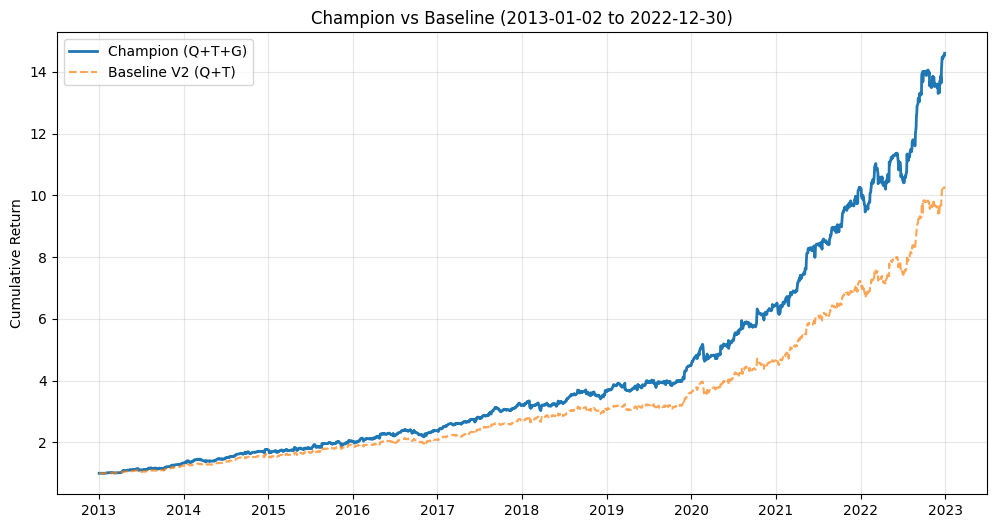

In [21]:
results = run_champion_v2_gld_backtest(
    df_q=df_q,
    df_t=df_t,
    df_g=df_g,
    start="2013-01-02",
    end="2022-12-30",
    target_vol=0.15,
    plot=True
)

WALK-FORWARD ANALYSIS (Expanding Window)
[2019] Train: 2013-2018 | Test Return: 21.4%
       Weights: QQQ 0.55 | TLT 0.25 | GLD_Tr 0.10
[2020] Train: 2013-2019 | Test Return: 37.8%
       Weights: QQQ 0.54 | TLT 0.25 | GLD_Tr 0.11
[2021] Train: 2013-2020 | Test Return: 45.4%
       Weights: QQQ 0.47 | TLT 0.28 | GLD_Tr 0.12
[2022] Train: 2013-2021 | Test Return: 37.1%
       Weights: QQQ 0.48 | TLT 0.29 | GLD_Tr 0.09
[2023] Train: 2013-2022 | Test Return: 30.7%
       Weights: QQQ 0.46 | TLT 0.30 | GLD_Tr 0.10
[2024] Train: 2013-2023 | Test Return: 24.2%
       Weights: QQQ 0.48 | TLT 0.32 | GLD_Tr 0.08
[2025] Train: 2013-2024 | Test Return: 36.8%
       Weights: QQQ 0.49 | TLT 0.29 | GLD_Tr 0.07
[2026] Train: 2013-2025 | Test Return: 3.7%
       Weights: QQQ 0.46 | TLT 0.26 | GLD_Tr 0.09

FINAL RESULTS (2019-2026)
     Metric  Champion (WF)  V2 Baseline  QQQ B&H
     Sharpe           2.13         1.98     0.94
Ann. Return           0.34         0.29     0.23
     Max DD          -0.11

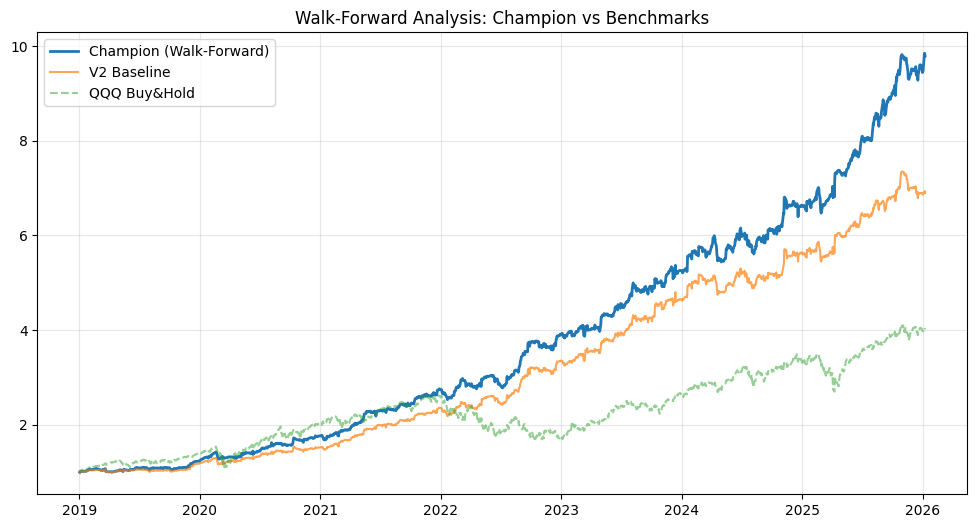

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =============================================================================
# 1. Core Helper Functions (Signals, Vol Targeting, Stats)
# =============================================================================

def vol_target_series(ret, target_vol=0.15, clip=1.5):
    # Annualized rolling volatility (20-day)
    vol = ret.rolling(20).std() * np.sqrt(252)
    scaler = (target_vol / vol).replace([np.inf, -np.inf], 0).fillna(0)
    # Clip leverage
    scaler = scaler.clip(0, clip)
    # Shift 1 day to avoid lookahead
    return scaler.shift(1).fillna(1.0)

def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def series_stats(series):
    if series.empty: return {}
    s = series.dropna()
    ann_ret = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    cum = (1 + s).cumprod()
    if len(cum) == 0: return {}

    cagr = cum.iloc[-1]**(252 / len(s)) - 1
    dd = cum / cum.cummax() - 1

    return {
        "Sharpe": sharpe,
        "AnnRet": ann_ret,
        "AnnVol": ann_vol,
        "MaxDD": dd.min(),
        "CAGR": cagr
    }

def get_sleeve_returns(df_qqq, df_tlt):
    # QQQ Signals
    c_q = df_qqq["Close"]; ret_q = df_qqq["Return"]

    # VAM
    vam = (ret_q.rolling(126).mean() * 252) / ret_q.rolling(126).std() * np.sqrt(252)
    s_vam = (vam > 0.3).astype(float)

    # MACD
    macd = c_q.ewm(span=8).mean() - c_q.ewm(span=26).mean()
    sig = macd.ewm(span=9).mean()
    trend = c_q > c_q.rolling(150).mean()
    s_macd = pd.Series(0.0, index=df_qqq.index)
    s_macd[(macd > sig) & trend] = 1.0
    s_macd[(macd < sig) & (~trend)] = -1.0

    # RSI
    r3 = calc_rsi(c_q, 3)
    sma150 = c_q.rolling(150).mean()
    s_rsi = pd.Series(0.0, index=df_qqq.index)
    s_rsi[(c_q > sma150) & (r3 < 10)] = 1.0
    s_rsi[(c_q < sma150) & (r3 > 90)] = -1.0

    # BB
    sma20 = c_q.rolling(20).mean(); std20 = c_q.rolling(20).std()
    s_bb = pd.Series(0.0, index=df_qqq.index)
    s_bb[c_q < sma20 - 2.0 * std20] = 1.0
    s_bb[c_q > sma20 + 2.0 * std20] = -1.0

    # IBS
    rng = (df_qqq["High"] - df_qqq["Low"])
    ibs = (c_q - df_qqq["Low"]) / rng
    s_ibs = pd.Series(0.0, index=df_qqq.index)
    s_ibs[ibs < 0.25] = 1.0; s_ibs[ibs > 0.9] = -1.0

    # Cris
    ret3 = c_q.pct_change(3)
    z = (ret3 - ret3.rolling(60).mean()) / ret3.rolling(60).std()
    s_cris = pd.Series(0.0, index=df_qqq.index)
    s_cris[z < -1.5] = 1.0; s_cris[z > 2.5] = -1.0

    # Sqz
    bb_w = (std20 * 4) / sma20
    sqz = bb_w < bb_w.rolling(126).quantile(0.25)
    h20 = df_qqq["High"].rolling(20).max().shift(1)
    l20 = df_qqq["Low"].rolling(20).min().shift(1)
    s_sqz = pd.Series(0.0, index=df_qqq.index)
    s_sqz[sqz & (c_q > h20)] = 1.0; s_sqz[sqz & (c_q < l20)] = -1.0

    # Vix
    h_roll = c_q.rolling(20).max()
    wf = (h_roll - df_qqq["Low"]) / h_roll
    s_vix = (wf.rolling(126).rank(pct=True) > 0.9).astype(float)

    # Tom/Mid
    dom = df_qqq.index.day
    s_tom = pd.Series(0.0, index=df_qqq.index)
    s_tom[((dom >= 25) | (dom <= 3)) & (c_q > sma150)] = 1.0
    s_mid = pd.Series(0.0, index=df_qqq.index)
    s_mid[((dom >= 10) & (dom <= 16)) & (c_q > sma150)] = 1.0

    # Liq
    eff = (c_q - df_qqq["Open"]).abs() / rng
    v_ma = df_qqq["Volume"].rolling(20).mean()
    sma50 = c_q.rolling(50).mean()
    s_liq = pd.Series(0.0, index=df_qqq.index)
    s_liq[(c_q > sma50) & ((df_qqq["Volume"] < v_ma) | (eff > 0.55))] = 1.0
    s_liq[(c_q < sma50) & (df_qqq["Volume"] > 1.2 * v_ma)] = -1.0

    wq = {"VAM":0.129, "MACD":0.075, "RSI":0.325, "BB":-0.063, "IBS":0.06,
          "Cris":0.384, "Sqz":0.985, "Vix":0.055, "Tom":-0.3, "Mid":0.187, "Liq":0.138}

    raw_pos_q = (s_vam*wq["VAM"] + s_macd*wq["MACD"] + s_rsi*wq["RSI"] + s_bb*wq["BB"] +
                 s_ibs*wq["IBS"] + s_cris*wq["Cris"] + s_sqz*wq["Sqz"] + s_vix*wq["Vix"] +
                 s_tom*wq["Tom"] + s_mid*wq["Mid"] + s_liq*wq["Liq"])

    # TLT Signals
    c_t = df_tlt["Close"]; ret_t = df_tlt["Return"]
    roc = c_t.pct_change(126)
    s_mom = pd.Series(0.0, index=df_tlt.index); s_mom[roc > 0] = 1.0; s_mom[roc < 0] = -1.0
    trsi = calc_rsi(c_t, 3)
    s_trsi = pd.Series(0.0, index=df_tlt.index); s_trsi[trsi < 10] = 1.0; s_trsi[trsi > 90] = -1.0
    tsma = c_t.rolling(150).mean()
    s_trend = pd.Series(0.0, index=df_tlt.index); s_trend[c_t > tsma] = 1.0; s_trend[c_t < tsma] = -1.0
    tv_ma = df_tlt["Volume"].rolling(20).mean()
    s_cap = pd.Series(0.0, index=df_tlt.index)
    s_cap[(ret_t < -0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = 1.0
    s_cap[(ret_t > 0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = -1.0

    wt = {"Mom":0.26, "RSI":0.613, "Trend":-0.04, "Cap":1.422}
    raw_pos_t = (s_mom*wt["Mom"] + s_trsi*wt["RSI"] + s_trend*wt["Trend"] + s_cap*wt["Cap"])

    return raw_pos_q.shift(1) * ret_q, raw_pos_t.shift(1) * ret_t

# =============================================================================
# 2. Optimization & Application Functions
# =============================================================================

def fit_champion_weights(df_q, df_t, df_g, start, end, target_vol=0.15):
    """
    Fits weights using ONLY data in [start, end].
    Returns the fitted weights to be used in the future.
    """
    # Get base sleeves
    q_ret, t_ret = get_sleeve_returns(df_q, df_t)

    # GLD Signals
    c_g = df_g["Close"]; ret_g = df_g["Return"]

    ma20 = c_g.rolling(20).mean(); ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=df_g.index); pos_gt[ma20 > ma60] = 1.0; pos_gt[ma20 < ma60] = -1.0
    gld_trend = pos_gt.shift(1) * ret_g

    groups = pd.Series(df_g.index, index=df_g.index).groupby(pd.Grouper(freq="ME"))
    td_mask = pd.Series(0.0, index=df_g.index)
    for _, grp in groups:
        if len(grp) < 5: continue
        td_mask.loc[grp.index[-1]] = 1.0
        td_mask.loc[grp.index[:3]] = 1.0
    gld_seas = td_mask.shift(-1).shift(1).fillna(0) * ret_g # Shift logic preserved

    sma = c_g.rolling(20).mean(); std = c_g.rolling(20).std(); bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60)
    pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol = pos_gv.shift(1) * ret_g

    sleeves = pd.DataFrame({
        "QQQ_sleeve": q_ret, "TLT_sleeve": t_ret,
        "GLD_trend": gld_trend, "GLD_seas": gld_seas, "GLD_vol": gld_vol
    }).fillna(0)

    # Apply Individual Vol Target (Clip 1.5)
    norm_sleeves = pd.DataFrame(index=sleeves.index)
    for c in sleeves.columns:
        s = vol_target_series(sleeves[c], target_vol, clip=1.5)
        norm_sleeves[c] = sleeves[c] * s

    # Slice to Fit Window
    common = df_q.index.intersection(df_t.index).intersection(df_g.index)
    idx = common[(common >= start) & (common <= end)]
    fit_data = norm_sleeves.loc[idx]

    def neg_sharpe(w):
        port = (fit_data * w).sum(axis=1)
        if port.std() == 0: return 0
        return -(port.mean() * 252) / (port.std() * np.sqrt(252))

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0})
    bnds = tuple([(0.05, 0.8) for _ in range(5)]) # Min 5% per sleeve
    res = minimize(neg_sharpe, [0.2]*5, bounds=bnds, constraints=cons, method='SLSQP')

    return dict(zip(sleeves.columns, np.round(res.x, 4)))

def apply_champion_weights(df_q, df_t, df_g, weights, start, end, target_vol=0.15):
    """
    Applies FIXED weights to [start, end].
    Calculates sleeves on full history to ensure scaler continuity, then slices.
    """
    # Re-calc sleeves (identical logic to fit)
    q_ret, t_ret = get_sleeve_returns(df_q, df_t)

    c_g = df_g["Close"]; ret_g = df_g["Return"]
    ma20 = c_g.rolling(20).mean(); ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=df_g.index); pos_gt[ma20 > ma60] = 1.0; pos_gt[ma20 < ma60] = -1.0
    gld_trend = pos_gt.shift(1) * ret_g

    groups = pd.Series(df_g.index, index=df_g.index).groupby(pd.Grouper(freq="ME"))
    td_mask = pd.Series(0.0, index=df_g.index)
    for _, grp in groups:
        if len(grp) < 5: continue
        td_mask.loc[grp.index[-1]] = 1.0; td_mask.loc[grp.index[:3]] = 1.0
    gld_seas = td_mask.shift(-1).shift(1).fillna(0) * ret_g

    sma = c_g.rolling(20).mean(); std = c_g.rolling(20).std(); bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60); pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol = pos_gv.shift(1) * ret_g

    sleeves = pd.DataFrame({
        "QQQ_sleeve": q_ret, "TLT_sleeve": t_ret,
        "GLD_trend": gld_trend, "GLD_seas": gld_seas, "GLD_vol": gld_vol
    }).fillna(0)

    norm_sleeves = pd.DataFrame(index=sleeves.index)
    for c in sleeves.columns:
        s = vol_target_series(sleeves[c], target_vol, clip=1.5)
        norm_sleeves[c] = sleeves[c] * s

    # Apply weights
    w_vec = [weights[c] for c in sleeves.columns]
    port_raw = (norm_sleeves * w_vec).sum(axis=1)

    # Portfolio Vol Target (Clip 2.5)
    final_s = vol_target_series(port_raw, target_vol, clip=2.5)
    port_final = port_raw * final_s

    # Slice
    common = df_q.index.intersection(df_t.index).intersection(df_g.index)
    idx = common[(common >= start) & (common <= end)]

    return port_final.loc[idx]

# =============================================================================
# 3. Walk-Forward Analysis Execution
# =============================================================================

def run_champion_walk_forward(df_q, df_t, df_g, initial_train_years=6):
    idx = df_q.index.intersection(df_t.index).intersection(df_g.index)
    years = sorted(list(set(idx.year)))
    test_years = years[initial_train_years:]

    oos_results = []
    weight_log = []

    print(f"{'='*60}")
    print(f"WALK-FORWARD ANALYSIS (Expanding Window)")
    print(f"{'='*60}")

    for year in test_years:
        # Define Windows
        train_start = f"{years[0]}-01-01"
        train_end = f"{year-1}-12-31"
        test_start = f"{year}-01-01"
        test_end = f"{year}-12-31"

        # 1. Train (Fit)
        weights = fit_champion_weights(df_q, df_t, df_g, train_start, train_end)

        # Log weights
        log_entry = weights.copy(); log_entry['Year'] = year
        weight_log.append(log_entry)

        # 2. Test (Apply)
        ret_test = apply_champion_weights(df_q, df_t, df_g, weights, test_start, test_end)
        oos_results.append(ret_test)

        print(f"[{year}] Train: {years[0]}-{year-1} | Test Return: {ret_test.sum():.1%}")
        print(f"       Weights: QQQ {weights['QQQ_sleeve']:.2f} | TLT {weights['TLT_sleeve']:.2f} | GLD_Tr {weights['GLD_trend']:.2f}")

    # Combine Results
    full_oos = pd.concat(oos_results)
    stats = series_stats(full_oos)

    # Benchmarks
    q_bh = df_q.loc[full_oos.index, "Return"]
    q_stats = series_stats(q_bh)

    # V2 Baseline (QQQ+TLT Fixed)
    q_s, t_s = get_sleeve_returns(df_q, df_t)
    v2 = 0.654*q_s + 0.346*t_s
    v2 = (v2 * vol_target_series(v2, 0.15, 2.5)).loc[full_oos.index]
    v2_stats = series_stats(v2)

    print(f"\n{'='*60}")
    print(f"FINAL RESULTS ({test_years[0]}-{test_years[-1]})")
    print(f"{'='*60}")

    res_df = pd.DataFrame({
        "Metric": ["Sharpe", "Ann. Return", "Max DD", "CAGR"],
        "Champion (WF)": [stats['Sharpe'], stats['AnnRet'], stats['MaxDD'], stats['CAGR']],
        "V2 Baseline": [v2_stats['Sharpe'], v2_stats['AnnRet'], v2_stats['MaxDD'], v2_stats['CAGR']],
        "QQQ B&H": [q_stats['Sharpe'], q_stats['AnnRet'], q_stats['MaxDD'], q_stats['CAGR']]
    })
    print(res_df.to_string(index=False, float_format="{:.2f}".format))

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot((1+full_oos).cumprod(), label="Champion (Walk-Forward)", linewidth=2)
    plt.plot((1+v2).cumprod(), label="V2 Baseline", alpha=0.7)
    plt.plot((1+q_bh).cumprod(), label="QQQ Buy&Hold", alpha=0.5, linestyle='--')
    plt.title("Walk-Forward Analysis: Champion vs Benchmarks")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Run it
run_champion_walk_forward(df_q, df_t, df_g)

In [23]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# =============================================================================
# 1. HELPER FUNCTIONS (Signals, Stats, Vol Targeting)
# =============================================================================

def series_stats(series):
    if series.empty: return {}
    s = series.dropna()
    if len(s) < 5: return {}
    ann_ret = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    cum = (1 + s).cumprod()
    if len(cum) == 0: return {}
    cagr = cum.iloc[-1]**(252 / len(s)) - 1
    dd = cum / cum.cummax() - 1

    return {
        "Sharpe": sharpe,
        "AnnRet": ann_ret,
        "AnnVol": ann_vol,
        "MaxDD": dd.min(),
        "CAGR": cagr
    }

def vol_target_series(ret, target_vol=0.15, clip=1.5):
    # 20-day rolling vol
    vol = ret.rolling(20).std() * np.sqrt(252)
    scaler = (target_vol / vol).replace([np.inf, -np.inf], 0).fillna(0)
    scaler = scaler.clip(0, clip)
    # Lag by 1 day to prevent lookahead
    return scaler.shift(1).fillna(1.0)

def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def get_sleeve_returns(df_qqq, df_tlt):
    # --- QQQ Signals ---
    c_q = df_qqq["Close"]; ret_q = df_qqq["Return"]

    vam = (ret_q.rolling(126).mean() * 252) / ret_q.rolling(126).std() * np.sqrt(252)
    s_vam = (vam > 0.3).astype(float)

    macd = c_q.ewm(span=8).mean() - c_q.ewm(span=26).mean()
    sig = macd.ewm(span=9).mean()
    trend = c_q > c_q.rolling(150).mean()
    s_macd = pd.Series(0.0, index=df_qqq.index)
    s_macd[(macd > sig) & trend] = 1.0
    s_macd[(macd < sig) & (~trend)] = -1.0

    r3 = calc_rsi(c_q, 3)
    sma150 = c_q.rolling(150).mean()
    s_rsi = pd.Series(0.0, index=df_qqq.index)
    s_rsi[(c_q > sma150) & (r3 < 10)] = 1.0
    s_rsi[(c_q < sma150) & (r3 > 90)] = -1.0

    sma20 = c_q.rolling(20).mean(); std20 = c_q.rolling(20).std()
    s_bb = pd.Series(0.0, index=df_qqq.index)
    s_bb[c_q < sma20 - 2.0 * std20] = 1.0
    s_bb[c_q > sma20 + 2.0 * std20] = -1.0

    rng = (df_qqq["High"] - df_qqq["Low"])
    ibs = (c_q - df_qqq["Low"]) / rng
    s_ibs = pd.Series(0.0, index=df_qqq.index)
    s_ibs[ibs < 0.25] = 1.0; s_ibs[ibs > 0.9] = -1.0

    ret3 = c_q.pct_change(3)
    z = (ret3 - ret3.rolling(60).mean()) / ret3.rolling(60).std()
    s_cris = pd.Series(0.0, index=df_qqq.index)
    s_cris[z < -1.5] = 1.0; s_cris[z > 2.5] = -1.0

    bb_w = (std20 * 4) / sma20
    sqz = bb_w < bb_w.rolling(126).quantile(0.25)
    h20 = df_qqq["High"].rolling(20).max().shift(1)
    l20 = df_qqq["Low"].rolling(20).min().shift(1)
    s_sqz = pd.Series(0.0, index=df_qqq.index)
    s_sqz[sqz & (c_q > h20)] = 1.0; s_sqz[sqz & (c_q < l20)] = -1.0

    h_roll = c_q.rolling(20).max()
    wf = (h_roll - df_qqq["Low"]) / h_roll
    s_vix = (wf.rolling(126).rank(pct=True) > 0.9).astype(float)

    dom = df_qqq.index.day
    s_tom = pd.Series(0.0, index=df_qqq.index)
    s_tom[((dom >= 25) | (dom <= 3)) & (c_q > sma150)] = 1.0
    s_mid = pd.Series(0.0, index=df_qqq.index)
    s_mid[((dom >= 10) & (dom <= 16)) & (c_q > sma150)] = 1.0

    eff = (c_q - df_qqq["Open"]).abs() / rng
    v_ma = df_qqq["Volume"].rolling(20).mean()
    sma50 = c_q.rolling(50).mean()
    s_liq = pd.Series(0.0, index=df_qqq.index)
    s_liq[(c_q > sma50) & ((df_qqq["Volume"] < v_ma) | (eff > 0.55))] = 1.0
    s_liq[(c_q < sma50) & (df_qqq["Volume"] > 1.2 * v_ma)] = -1.0

    wq = {"VAM":0.129, "MACD":0.075, "RSI":0.325, "BB":-0.063, "IBS":0.06,
          "Cris":0.384, "Sqz":0.985, "Vix":0.055, "Tom":-0.3, "Mid":0.187, "Liq":0.138}

    raw_pos_q = (s_vam*wq["VAM"] + s_macd*wq["MACD"] + s_rsi*wq["RSI"] + s_bb*wq["BB"] +
                 s_ibs*wq["IBS"] + s_cris*wq["Cris"] + s_sqz*wq["Sqz"] + s_vix*wq["Vix"] +
                 s_tom*wq["Tom"] + s_mid*wq["Mid"] + s_liq*wq["Liq"])

    # --- TLT Signals ---
    c_t = df_tlt["Close"]; ret_t = df_tlt["Return"]
    roc = c_t.pct_change(126)
    s_mom = pd.Series(0.0, index=df_tlt.index); s_mom[roc > 0] = 1.0; s_mom[roc < 0] = -1.0
    trsi = calc_rsi(c_t, 3)
    s_trsi = pd.Series(0.0, index=df_tlt.index); s_trsi[trsi < 10] = 1.0; s_trsi[trsi > 90] = -1.0
    tsma = c_t.rolling(150).mean()
    s_trend = pd.Series(0.0, index=df_tlt.index); s_trend[c_t > tsma] = 1.0; s_trend[c_t < tsma] = -1.0
    tv_ma = df_tlt["Volume"].rolling(20).mean()
    s_cap = pd.Series(0.0, index=df_tlt.index)
    s_cap[(ret_t < -0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = 1.0
    s_cap[(ret_t > 0.015) & (df_tlt["Volume"] > 1.3 * tv_ma)] = -1.0

    wt = {"Mom":0.26, "RSI":0.613, "Trend":-0.04, "Cap":1.422}
    raw_pos_t = (s_mom*wt["Mom"] + s_trsi*wt["RSI"] + s_trend*wt["Trend"] + s_cap*wt["Cap"])

    return raw_pos_q.shift(1) * ret_q, raw_pos_t.shift(1) * ret_t

# =============================================================================
# 2. FIT & APPLY FUNCTIONS
# =============================================================================

def fit_champion_weights(df_q, df_t, df_g, start, end, target_vol=0.15):
    """
    Fits optimal weights using ONLY data between start and end.
    """
    q_ret, t_ret = get_sleeve_returns(df_q, df_t)

    # GLD Sleeves
    c_g = df_g["Close"]; ret_g = df_g["Return"]
    ma20 = c_g.rolling(20).mean(); ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=df_g.index); pos_gt[ma20 > ma60] = 1.0; pos_gt[ma20 < ma60] = -1.0
    gld_trend = pos_gt.shift(1) * ret_g

    groups = pd.Series(df_g.index, index=df_g.index).groupby(pd.Grouper(freq="ME"))
    td_mask = pd.Series(0.0, index=df_g.index)
    for _, grp in groups:
        if len(grp) < 5: continue
        td_mask.loc[grp.index[-1]] = 1.0; td_mask.loc[grp.index[:3]] = 1.0
    gld_seas = td_mask.shift(-1).shift(1).fillna(0) * ret_g

    sma = c_g.rolling(20).mean(); std = c_g.rolling(20).std(); bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60)
    pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol = pos_gv.shift(1) * ret_g

    sleeves = pd.DataFrame({
        "QQQ_sleeve": q_ret, "TLT_sleeve": t_ret,
        "GLD_trend": gld_trend, "GLD_seas": gld_seas, "GLD_vol": gld_vol
    }).fillna(0)

    # Normalize
    norm_sleeves = pd.DataFrame(index=sleeves.index)
    for c in sleeves.columns:
        s = vol_target_series(sleeves[c], target_vol, clip=1.5)
        norm_sleeves[c] = sleeves[c] * s

    # Slice for optimization
    common = df_q.index.intersection(df_t.index).intersection(df_g.index)
    idx = common[(common >= start) & (common <= end)]
    fit_data = norm_sleeves.loc[idx]

    def neg_sharpe(w):
        port = (fit_data * w).sum(axis=1)
        if port.std() == 0: return 0
        return -(port.mean() * 252) / (port.std() * np.sqrt(252))

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0})
    bnds = tuple([(0.05, 0.8) for _ in range(5)])
    res = minimize(neg_sharpe, [0.2]*5, bounds=bnds, constraints=cons, method='SLSQP')
    return dict(zip(sleeves.columns, np.round(res.x, 4)))

def apply_champion_weights(df_q, df_t, df_g, weights, start, end, target_vol=0.15):
    """
    Applies FIXED weights to [start, end] without re-optimizing.
    """
    # Re-calculate sleeves (same logic)
    q_ret, t_ret = get_sleeve_returns(df_q, df_t)
    c_g = df_g["Close"]; ret_g = df_g["Return"]
    ma20 = c_g.rolling(20).mean(); ma60 = c_g.rolling(60).mean()
    pos_gt = pd.Series(0.0, index=df_g.index); pos_gt[ma20 > ma60] = 1.0; pos_gt[ma20 < ma60] = -1.0
    gld_trend = pos_gt.shift(1) * ret_g
    groups = pd.Series(df_g.index, index=df_g.index).groupby(pd.Grouper(freq="ME"))
    td_mask = pd.Series(0.0, index=df_g.index)
    for _, grp in groups:
        if len(grp) < 5: continue
        td_mask.loc[grp.index[-1]] = 1.0; td_mask.loc[grp.index[:3]] = 1.0
    gld_seas = td_mask.shift(-1).shift(1).fillna(0) * ret_g
    sma = c_g.rolling(20).mean(); std = c_g.rolling(20).std(); bw = (4 * std) / sma
    sqz_thresh = bw.rolling(126).quantile(0.60); pos_gv = (bw < sqz_thresh).astype(float)
    gld_vol = pos_gv.shift(1) * ret_g

    sleeves = pd.DataFrame({
        "QQQ_sleeve": q_ret, "TLT_sleeve": t_ret,
        "GLD_trend": gld_trend, "GLD_seas": gld_seas, "GLD_vol": gld_vol
    }).fillna(0)

    norm_sleeves = pd.DataFrame(index=sleeves.index)
    for c in sleeves.columns:
        s = vol_target_series(sleeves[c], target_vol, clip=1.5)
        norm_sleeves[c] = sleeves[c] * s

    # Apply weights
    w_vec = [weights[c] for c in sleeves.columns]
    port_raw = (norm_sleeves * w_vec).sum(axis=1)

    # Vol Target Portfolio
    final_s = vol_target_series(port_raw, target_vol, clip=2.5)
    port_final = port_raw * final_s

    # Slice
    common = df_q.index.intersection(df_t.index).intersection(df_g.index)
    idx = common[(common >= start) & (common <= end)]
    return port_final.loc[idx]

# =============================================================================
# 3. WALK-FORWARD EXECUTION
# =============================================================================

def run_champion_walk_forward_detailed(df_q, df_t, df_g, initial_train_years=6):
    idx = df_q.index.intersection(df_t.index).intersection(df_g.index)
    years = sorted(list(set(idx.year)))
    if len(years) <= initial_train_years:
        print("Not enough data for WF.")
        return

    test_years = years[initial_train_years:]
    oos_results = []
    yearly_metrics = []

    print(f"{'='*70}")
    print(f"WALK-FORWARD ANALYSIS: YEARLY BREAKDOWN")
    print(f"{'='*70}")

    for year in test_years:
        # Sliding Window: Train on ALL history up to 'year'
        train_start = f"{years[0]}-01-01"
        train_end = f"{year-1}-12-31"
        test_start = f"{year}-01-01"
        test_end = f"{year}-12-31"

        # 1. Train (Fit Weights)
        weights = fit_champion_weights(df_q, df_t, df_g, train_start, train_end)

        # 2. Test (Apply Weights)
        ret_test = apply_champion_weights(df_q, df_t, df_g, weights, test_start, test_end)
        oos_results.append(ret_test)

        # 3. Stats
        stats = series_stats(ret_test)
        gld_total = weights['GLD_trend'] + weights['GLD_seas'] + weights['GLD_vol']

        yearly_metrics.append({
            "Year": year,
            "Sharpe": stats.get('Sharpe', 0),
            "Return": stats.get('AnnRet', 0),
            "MaxDD": stats.get('MaxDD', 0),
            "QQQ_W": weights['QQQ_sleeve'],
            "TLT_W": weights['TLT_sleeve'],
            "GLD_W": gld_total
        })

        print(f"[{year}] Sharpe: {stats.get('Sharpe', 0):.2f} | Return: {stats.get('AnnRet', 0):.1%} | MaxDD: {stats.get('MaxDD', 0):.1%}")
        print(f"       Weights -> QQQ: {weights['QQQ_sleeve']:.0%} | TLT: {weights['TLT_sleeve']:.0%} | GLD: {gld_total:.0%}")
        print("-" * 70)

    # Combine
    full_oos = pd.concat(oos_results)
    total_stats = series_stats(full_oos)

    print(f"\n{'='*70}")
    print(f"FULL WALK-FORWARD SUMMARY ({test_years[0]}-{test_years[-1]})")
    print(f"{'='*70}")
    print(f"Total Sharpe:    {total_stats['Sharpe']:.2f}")
    print(f"Total CAGR:      {total_stats['CAGR']:.1%}")
    print(f"Total MaxDD:     {total_stats['MaxDD']:.1%}")

    return full_oos, pd.DataFrame(yearly_metrics)
run_champion_walk_forward_detailed(df_q, df_t, df_g)

WALK-FORWARD ANALYSIS: YEARLY BREAKDOWN
[2019] Sharpe: 1.53 | Return: 21.4% | MaxDD: -6.9%
       Weights -> QQQ: 55% | TLT: 25% | GLD: 20%
----------------------------------------------------------------------
[2020] Sharpe: 2.06 | Return: 37.6% | MaxDD: -10.7%
       Weights -> QQQ: 54% | TLT: 25% | GLD: 21%
----------------------------------------------------------------------
[2021] Sharpe: 3.09 | Return: 45.4% | MaxDD: -5.7%
       Weights -> QQQ: 47% | TLT: 28% | GLD: 25%
----------------------------------------------------------------------
[2022] Sharpe: 2.21 | Return: 37.2% | MaxDD: -8.7%
       Weights -> QQQ: 48% | TLT: 29% | GLD: 23%
----------------------------------------------------------------------
[2023] Sharpe: 1.98 | Return: 31.0% | MaxDD: -5.6%
       Weights -> QQQ: 46% | TLT: 30% | GLD: 23%
----------------------------------------------------------------------
[2024] Sharpe: 1.48 | Return: 24.2% | MaxDD: -9.3%
       Weights -> QQQ: 48% | TLT: 32% | GLD: 20%
----

(Date
 2019-01-02   -0.004689
 2019-01-03    0.013965
 2019-01-04    0.003692
 2019-01-07    0.001548
 2019-01-08   -0.000187
                 ...   
 2026-01-02    0.003037
 2026-01-05    0.028355
 2026-01-06    0.011238
 2026-01-07   -0.000555
 2026-01-08   -0.005358
 Length: 1765, dtype: float64,
    Year    Sharpe    Return     MaxDD   QQQ_W   TLT_W   GLD_W
 0  2019  1.531953  0.213590 -0.068708  0.5517  0.2510  0.1974
 1  2020  2.064547  0.376376 -0.107424  0.5429  0.2517  0.2054
 2  2021  3.093936  0.453943 -0.057134  0.4696  0.2800  0.2504
 3  2022  2.211672  0.372296 -0.087163  0.4816  0.2851  0.2334
 4  2023  1.978368  0.309873 -0.055851  0.4637  0.3033  0.2330
 5  2024  1.481755  0.242379 -0.092922  0.4832  0.3214  0.1954
 6  2025  2.442299  0.371277 -0.077021  0.4900  0.2906  0.2193
 7  2026  8.818813  1.850530 -0.005910  0.4579  0.2608  0.2814)